# 02 · Ventanas y splits

Apila las ventanas deslizantes, parte el dataset por fecha con embargo, escala
con train y deja `data/processed/ventanas.npz`, que es el único fichero que leen
los once cuadernos siguientes.

**Entradas:** `canales.parquet` · `objetivos.parquet` · `regimenes.parquet`

**Salidas:** `data/processed/ventanas.npz` · 2 figuras · 1 tabla en `results/metricas/`

**Tiempo:** ~15 s.

In [1]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import calidad, evaluacion, regimenes, ventanas

config.cargar_catalogo.cache_clear()

## 1 · La huella de una ventana son 81 sesiones, no 60

`X` cubre los 60 días de mercado anteriores a `t` inclusive, e `Y` describe los
21 posteriores. Así que una muestra **toca 81 sesiones**, no 60, y ese número es
el que gobierna todo lo demás:

- Dos ventanas consecutivas comparten **59 de sus 60 días**. El dataset se cuenta
  a sí mismo unas 80 veces.
- Para que dos ventanas no compartan ni una sesión tienen que estar separadas por
  al menos **80 posiciones**.

De ahí sale el embargo, y de ahí sale que el split tenga que ser temporal. Un
`train_test_split` aleatorio —lo que hacen los cuadernos guiados del máster—
pondría ventanas casi idénticas a los dos lados del corte, y las métricas
medirían memorización.

In [3]:
canales = pd.read_parquet(src.DIR_PROCESADO / "canales.parquet")
objetivos = pd.read_parquet(src.DIR_PROCESADO / "objetivos.parquet")
tabla_regimenes = pd.read_parquet(src.DIR_PROCESADO / "regimenes.parquet")

v, p = config.ventanas(), config.particiones()
conjunto = ventanas.construir_ventanas(
    canales=canales, regimen_futuro=tabla_regimenes["regimen_futuro"],
    vol_futura=objetivos["vol_futura"], ventanas=v)

print("X:", conjunto.X.shape, "· y_reg:", conjunto.y_reg.shape, "· y_vol:", conjunto.y_vol.shape)
print("De", conjunto.fechas[0].date(), "a", conjunto.fechas[-1].date())
print("Huella de una ventana:", v.pasado, "+", v.horizonte, "=", v.pasado + v.horizonte,
      "sesiones · separación mínima entre ventanas disjuntas:", v.solape_maximo)

X: (5590, 60, 20) · y_reg: (5590,) · y_vol: (5590,)
De 2004-04-27 a 2026-07-16
Huella de una ventana: 60 + 21 = 81 sesiones · separación mínima entre ventanas disjuntas: 80


## 2 · El embargo estaba contado en días naturales

El catálogo pedía 85 y la documentación decía "85 **sesiones**". El código lo
aplicaba con `pd.Timedelta(days=85)`, es decir, 85 **días naturales**.

No es lo mismo: en el calendario de la NYSE, 85 días naturales son **59 sesiones**,
y hacen falta 81. La tabla de abajo mide lo que eso costaba.

`auditar_solape` no resta fechas —restar fechas es justamente lo que produjo el
fallo— sino que construye el conjunto de posiciones que toca cada partición y los
intersecta. La columna que importa es `sesiones_compartidas`, y tiene que ser cero.

In [4]:
partes_malas = ventanas.partir_por_dias_naturales(conjunto, p.train_hasta, p.val_hasta, 85)
nombres = ("train", "validación", "test")
solape_malo = ventanas.auditar_solape(dict(zip(nombres, partes_malas)), v, canales.index)

print("Embargo aplicado como 85 días naturales:")
solape_malo[["hueco_sesiones", "minimo_exigido", "sesiones_compartidas", "desde", "hasta", "ok"]]

Embargo aplicado como 85 días naturales:


,hueco_sesiones,minimo_exigido,sesiones_compartidas,desde,hasta,ok
frontera,,,,,,
train | validación,59,81,22,2018-12-31,2019-01-31,False
train | test,816,81,0,NaT,NaT,True
validación | test,59,81,22,2021-12-31,2022-02-01,False


## 3 · Parchear el número o arreglar la unidad

Dos formas de cerrar la fuga. La tabla decide.

| opción | qué hace |
|---|---|
| subir los días naturales | busca un número que hoy funcione: 119, 125… |
| contar el embargo en sesiones | mide en la unidad correcta |

La columna que decide es **`cortes_cortos_pct`**: el porcentaje de fechas de corte
posibles del panel para las que ese número de días naturales **no llega** al hueco
mínimo. Con 119 falla en el 2,5 % de los cortes, y con 125 no falla pero descarta
más ventanas que la opción en sesiones.

Un embargo que funciona según dónde caigan los festivos es una coincidencia, no
una garantía. Se adopta **85 sesiones**: el valor del catálogo no cambia, cambia
la unidad en que se lee. El hueco resultante es cierto por construcción, y
`partir` ahora lanza si el embargo es menor que el solape.

In [5]:
ventanas.comparar_embargos(conjunto, p, v, canales.index)

,train,val,test,descartadas,solape,cortes_cortos_pct
embargo,,,,,,
85 días naturales,3696,699,1079,116,44,100.0
119 días naturales,3696,676,1055,163,0,2.0
125 días naturales,3696,672,1051,171,0,0.0
85 sesiones,3696,672,1052,170,0,0.0


## 4 · El split que se adopta

Tres tramos por fecha, cada uno con las crisis que le tocan: train llega a 2018 e
incluye 2008 y 2011; validación es el COVID; test es 2022 en adelante.

**Validación y test son siempre 100 % reales.** Lo único que cambiará entre las
versiones del cuaderno 12 es el conjunto de entrenamiento.

train        3696 ventanas · 2004-04-27 a 2018-12-31
validación    672 ventanas · 2019-05-06 a 2021-12-31
test         1052 ventanas · 2022-05-05 a 2026-07-16
Descartadas por el embargo: 170


,hueco_sesiones,minimo_exigido,sesiones_compartidas,ok
frontera,,,,
train | validación,86,81,0,True
train | test,843,81,0,True
validación | test,86,81,0,True


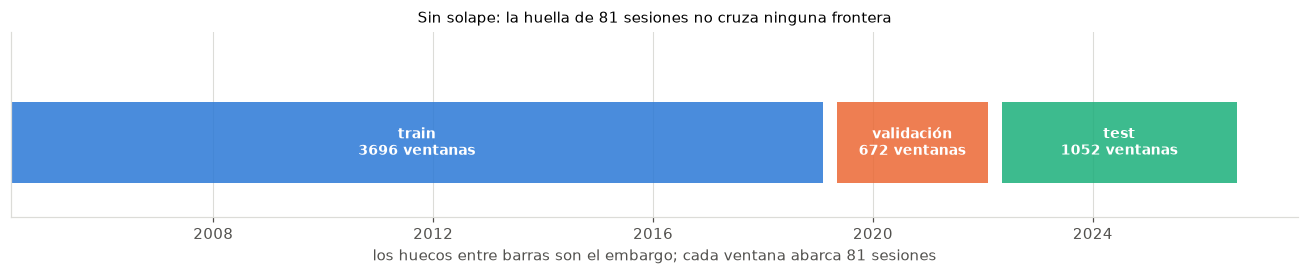

In [6]:
train, val, test = ventanas.partir(conjunto, p.train_hasta, p.val_hasta, p.embargo_sesiones, v)
particion = dict(zip(nombres, (train, val, test)))
solape = ventanas.auditar_solape(particion, v, canales.index)

for nombre, parte in particion.items():
    print(f"{nombre:<11} {len(parte.fechas):>5} ventanas · {parte.fechas[0].date()} a {parte.fechas[-1].date()}")
print("Descartadas por el embargo:", len(conjunto.fechas) - sum(len(x.fechas) for x in particion.values()))
assert solape["ok"].all(), "Hay sesiones en dos particiones a la vez."

fig, eje = plt.subplots(figsize=(12, 2.6))
viz.carril_particiones(particion, canales.index, v, solape, eje=eje)
viz.guardar(fig, "split_embargo")

solape[["hueco_sesiones", "minimo_exigido", "sesiones_compartidas", "ok"]]

## 5 · Integridad del dataset y escalado

Dos cosas antes de escribir nada.

**La auditoría.** Seis controles sobre `X`, `y_reg` e `y_vol`. Si alguno falla,
**no se imputa**: los canales ya vienen recortados del cuaderno 00 y
`construir_ventanas` ya descarta las posiciones sin objetivo, así que un NaN aquí
solo puede venir de un error aguas arriba y rellenarlo lo volvería silencioso.

**El escalado.** Media y desviación por canal, ajustadas **solo con train** y
aplicadas a las tres particiones. Por canal y no por posición temporal: un retorno
diario y un z-score del VIX no son comparables entre sí, pero dentro de un canal
todas las posiciones de la ventana sí lo son.

La prueba de que se ajustó solo con train está en la tabla siguiente: la columna
de train da media 0 y desviación 1; si validación y test dieran también 0 y 1, el
escalador habría visto lo que no debía.

In [7]:
control = calidad.auditar_ventanas(particion, config.n_regimenes())
media, desviacion = ventanas.ajustar_escalado(train)
escalado = {n: ventanas.escalar(c, media, desviacion) for n, c in particion.items()}

perfil = pd.concat(
    {"media": ventanas.perfil_por_canal(escalado, config.nombres_canales(), "media"),
     "desviación": ventanas.perfil_por_canal(escalado, config.nombres_canales(), "desviacion")},
    axis=1)

print(control.to_string())
print()
print("Perfil por canal tras escalar (primeros cinco canales):")
print(perfil.head(5).round(3).to_string())

                  veredicto  medida  limite                                     donde
control                                                                              
finitud_X                ok       0       0                       sin NaN ni inf en X
finitud_objetivos        ok       0       0                   sin NaN ni inf en y_vol
rango_regimen            ok       0       0                    y_reg dentro de [0, 3)
positividad_vol          ok       0       0                    mínimo de y_vol 0.0347
alineamiento             ok       0       0     longitudes iguales e índice creciente
clases_pobladas          ok     110      30  la más escasa es test/2 con 110 ventanas

Perfil por canal tras escalar (primeros cinco canales):
                      media                   desviación                  
                      train validación   test      train validación   test
ret_sp500               0.0      0.043  0.023        1.0      1.276  0.939
ret_sector_materiales  -0.0   

## 6 · Qué se lleva cada partición y qué ve el generador

**El reparto de clases no es el mismo en las tres**, y eso condiciona cómo se
leerán los resultados: dos generadores medidos sobre particiones con distinto
balance no son directamente comparables.

Y el número que de verdad limita cualquier intervalo de confianza no es el de
ventanas de crisis sino el de **rachas contiguas**: unas decenas de ventanas de
crisis en test son un puñado de episodios, y tratarlas como observaciones
independientes estrecha las bandas por un factor enorme.

**El bloque que consumen los generadores** no es `X`: es `[X aplanada ‖ y_vol]`,
de forma que cada muestra sintética viene con su objetivo de regresión coherente.
El régimen va aparte, como condición, para poder sobre-generar la clase de crisis
—que es el objetivo del taller— en vez de replicar el desbalance.

In [8]:
reparto = pd.DataFrame(
    {n: regimenes.distribucion(c.y_reg, config.n_regimenes())["porcentaje"] for n, c in particion.items()})
reparto.index = evaluacion.nombres_regimenes(config.n_regimenes())
rachas = {n: regimenes.tramos_contiguos(c.y_reg, config.n_regimenes() - 1) for n, c in particion.items()}

bloque = ventanas.empaquetar(escalado["train"])
print("Reparto de clases, en % de ventanas:")
print(reparto.round(1).to_string())
print("Ventanas de crisis y rachas contiguas ·",
      " · ".join(f"{n}: {int((c.y_reg == config.n_regimenes() - 1).sum())} en {rachas[n]} rachas"
                 for n, c in particion.items()))
print("Bloque para los generadores:", bloque.shape, "= 60 x 20 + 1")

Reparto de clases, en % de ventanas:
            train  validación  test
calma        54.6        18.3  33.0
transición   29.5        59.7  56.6
crisis       15.9        22.0  10.5
Ventanas de crisis y rachas contiguas · train: 587 en 8 rachas · validación: 148 en 2 rachas · test: 110 en 3 rachas
Bloque para los generadores: (3696, 1201) = 60 x 20 + 1


## Qué se lleva el resto del proyecto

- **`ventanas.npz`**, con las tres particiones ya escaladas y el escalador. Es lo
  único que abren los cuadernos 03 a 14.
- **Un split sin solape**, verificado por conteo de posiciones y no por resta de
  fechas.
- **El bloque de 1.201 dimensiones** que modelan los siete generadores.
- **Las rachas contiguas de crisis**, que son el tamaño muestral honesto para
  cualquier barra de error sobre la clase minoritaria.

## Salidas generadas

In [9]:
from pathlib import Path

src.DIR_METRICAS.mkdir(parents=True, exist_ok=True)
ruta = ventanas.guardar_procesado(ventanas.Particion(
    train=escalado["train"], val=escalado["validación"], test=escalado["test"],
    media=media, desviacion=desviacion))
reparto.round(2).to_csv(src.DIR_METRICAS / "reparto_particiones.csv")

salidas = [ruta, src.DIR_METRICAS / "reparto_particiones.csv",
           src.DIR_FIGURAS / "split_embargo.png"]

for r in salidas:
    r = Path(r)
    marca = "ok" if r.exists() else "--"
    print("[{}] {}".format(marca, r.relative_to(src.RAIZ)))

[ok] data\processed\ventanas.npz
[ok] results\metricas\reparto_particiones.csv
[ok] results\figures\split_embargo.png
